In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings('ignore')

In [19]:
df = pd.read_excel("mall_customers.xlsx")

print(df.head())

print(df.info())

print(df.describe())

   CustomerID Gender  Age   Education  Marital Status  Annual Income (k$)  \
0           1      M   19  High School        Married                  15   
1           2      M   21     Graduate         Single                  15   
2           3      F   20     Graduate        Married                  16   
3           4      F   23  High School        Unknown                  16   
4           5      F   31   Uneducated        Married                  17   

   Spending Score (1-100)  
0                      39  
1                      81  
2                       6  
3                      77  
4                      40  
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Education       

In [20]:
print("Shape:", df.shape)

print(df.isnull().sum())

print(df.duplicated().sum())

Shape: (200, 7)
CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
0


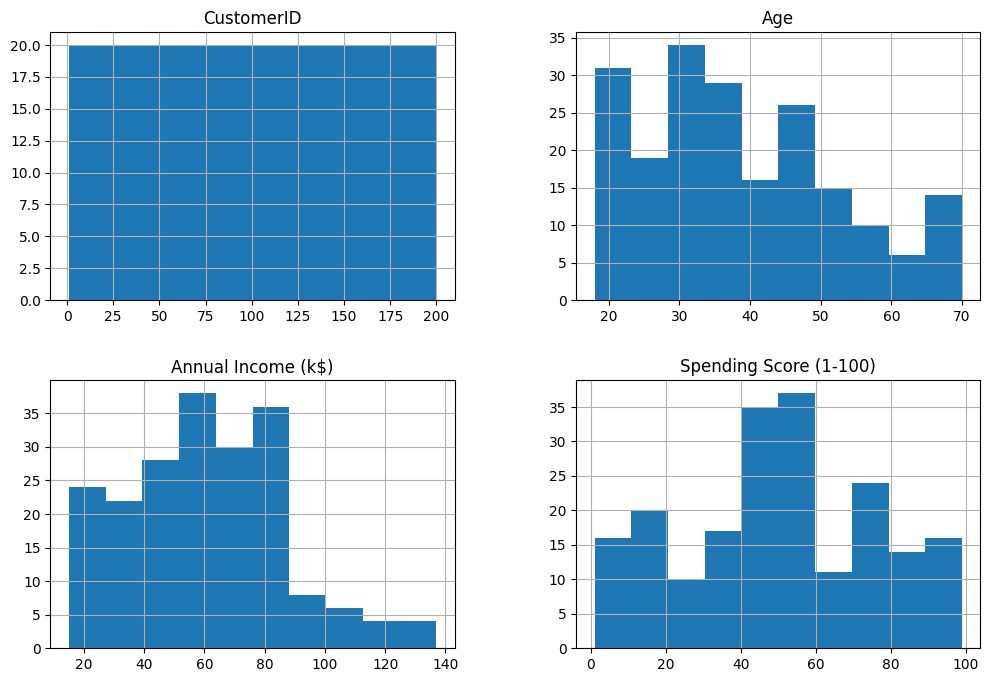

In [21]:
df.hist(figsize=(12,8))
plt.show()

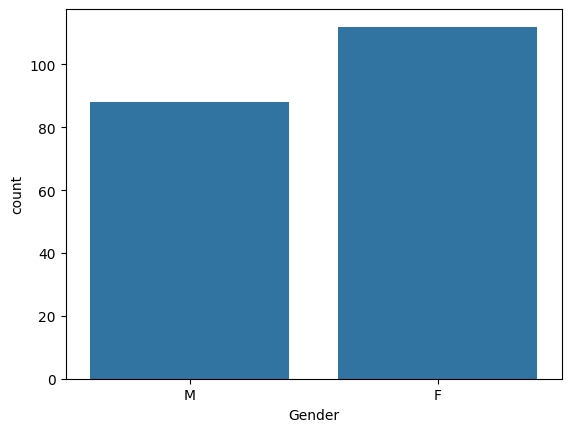

In [22]:
sns.countplot(x='Gender', data=df)
plt.show()

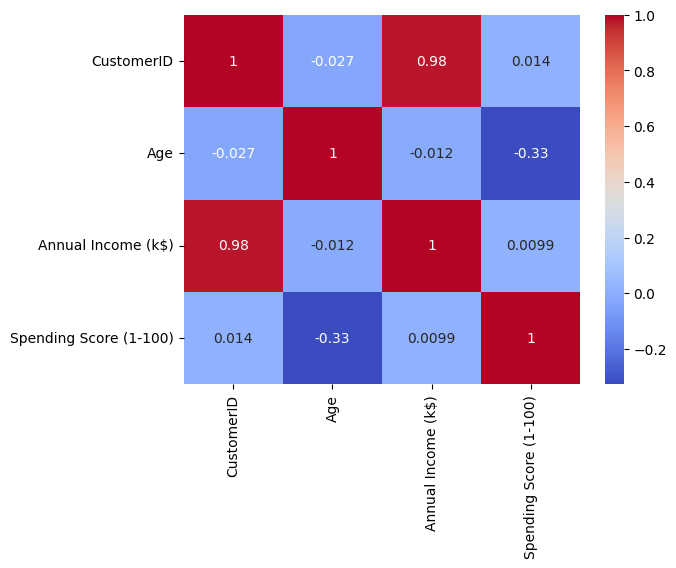

In [23]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

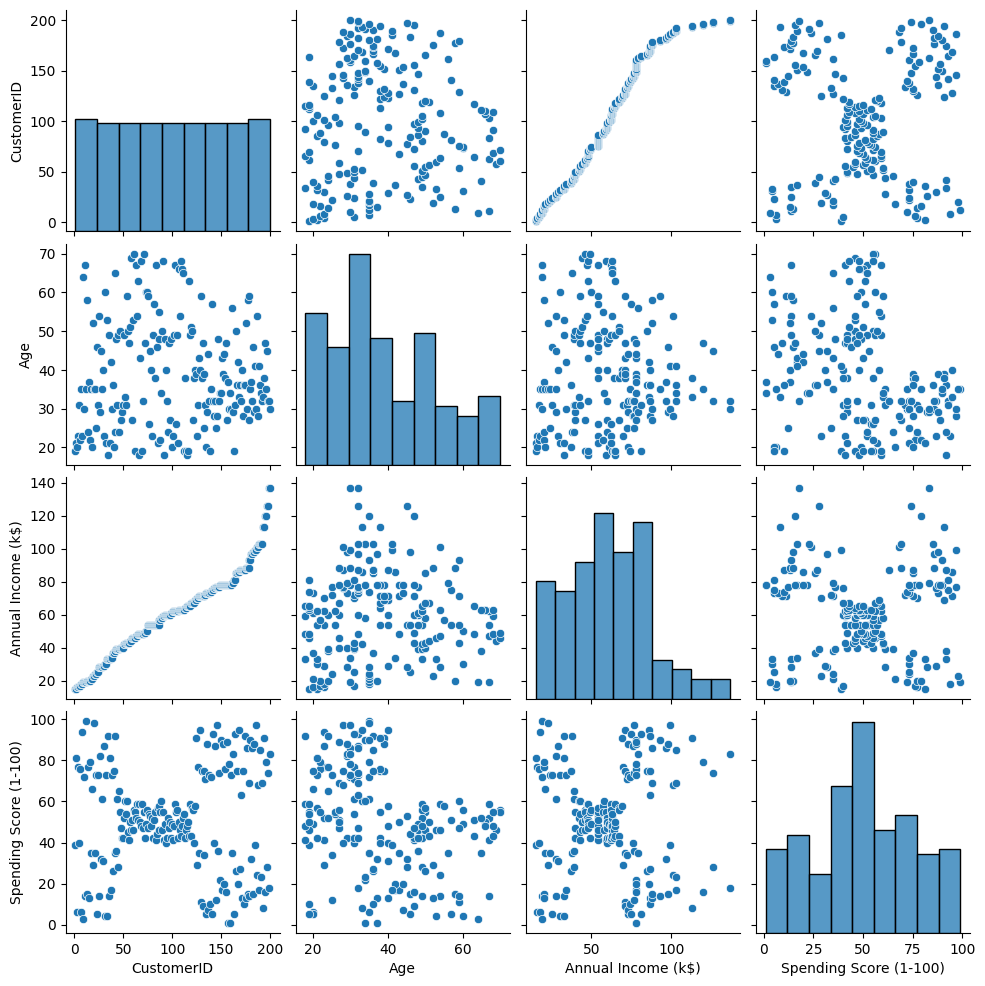

In [24]:
sns.pairplot(df)
plt.show()

In [25]:
df = df.drop_duplicates()

In [26]:
df = df.dropna()

In [27]:
df['Gender'] = df['Gender'].map({
    'Male':1,
    'Female':0
})

In [28]:
df = df.drop('CustomerID', axis=1)

In [31]:
df = df.drop('Gender', axis=1)

In [30]:
print(df.columns)

print(df.head())

print(df.dtypes)

Index(['Gender', 'Age', 'Education ', 'Marital Status', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')
   Gender  Age   Education  Marital Status  Annual Income (k$)  \
0     NaN   19  High School        Married                  15   
1     NaN   21     Graduate         Single                  15   
2     NaN   20     Graduate        Married                  16   
3     NaN   23  High School        Unknown                  16   
4     NaN   31   Uneducated        Married                  17   

   Spending Score (1-100)  
0                      39  
1                      81  
2                       6  
3                      77  
4                      40  
Gender                    float64
Age                         int64
Education                     str
Marital Status                str
Annual Income (k$)          int64
Spending Score (1-100)      int64
dtype: object


In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Education '] = le.fit_transform(df['Education '])

df['Marital Status'] = le.fit_transform(
    df['Marital Status']
)

In [33]:
print(df.head())
print(df.dtypes)

   Age  Education   Marital Status  Annual Income (k$)  Spending Score (1-100)
0   19           3               1                  15                      39
1   21           2               2                  15                      81
2   20           2               1                  16                       6
3   23           3               3                  16                      77
4   31           5               1                  17                      40
Age                       int64
Education                 int64
Marital Status            int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)

scaled_df.head()

,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-0.022543,-0.553667,-1.738999,-0.434801
1,-1.281035,-0.586122,0.848022,-1.738999,1.195704
2,-1.352802,-0.586122,-0.553667,-1.700830,-1.715913
3,-1.137502,-0.022543,2.249711,-1.700830,1.040418
4,-0.563369,1.104615,-0.553667,-1.662660,-0.395980


In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    scaled_df
)

print(pca.explained_variance_ratio_)

[0.27194991 0.22986307]


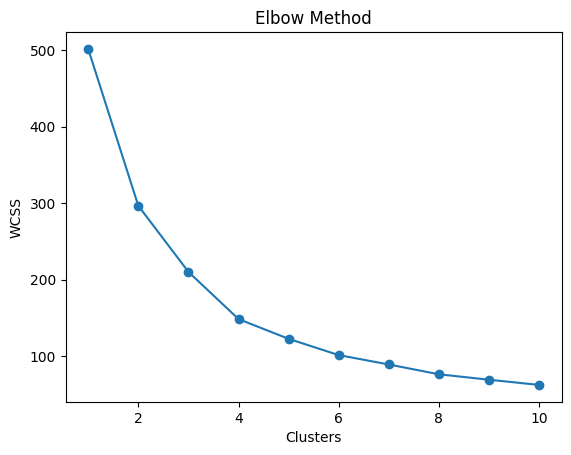

In [37]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(pca_data)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [38]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(
    pca_data
)

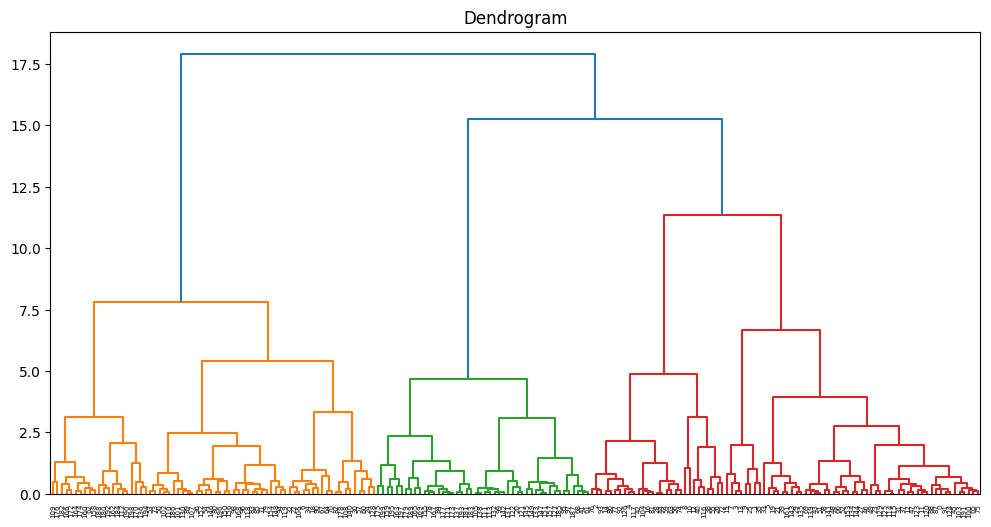

In [39]:
linked = linkage(
    pca_data,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Dendrogram")

plt.show()

In [40]:
hc = AgglomerativeClustering(
    n_clusters=5
)

hc_labels = hc.fit_predict(
    pca_data
)

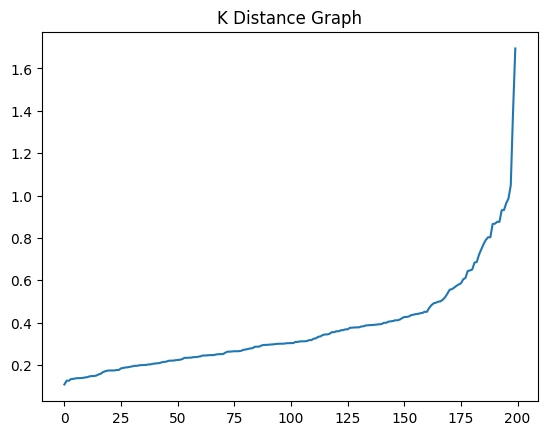

In [41]:
neighbors = NearestNeighbors(
    n_neighbors=5
)

neighbors_fit = neighbors.fit(
    pca_data
)

distances, indices = neighbors_fit.kneighbors(
    pca_data
)

distances = np.sort(
    distances[:,4]
)

plt.plot(distances)

plt.title("K Distance Graph")

plt.show()

In [42]:
dbscan = DBSCAN(
    eps=0.6,
    min_samples=5
)

db_labels = dbscan.fit_predict(
    pca_data
)

In [43]:
kmeans_score = silhouette_score(
    pca_data,
    kmeans_labels
)

In [44]:
hc_score = silhouette_score(
    pca_data,
    hc_labels
)

In [45]:
if len(set(db_labels)) > 1:

    db_score = silhouette_score(
        pca_data,
        db_labels
    )

else:
    db_score = -1

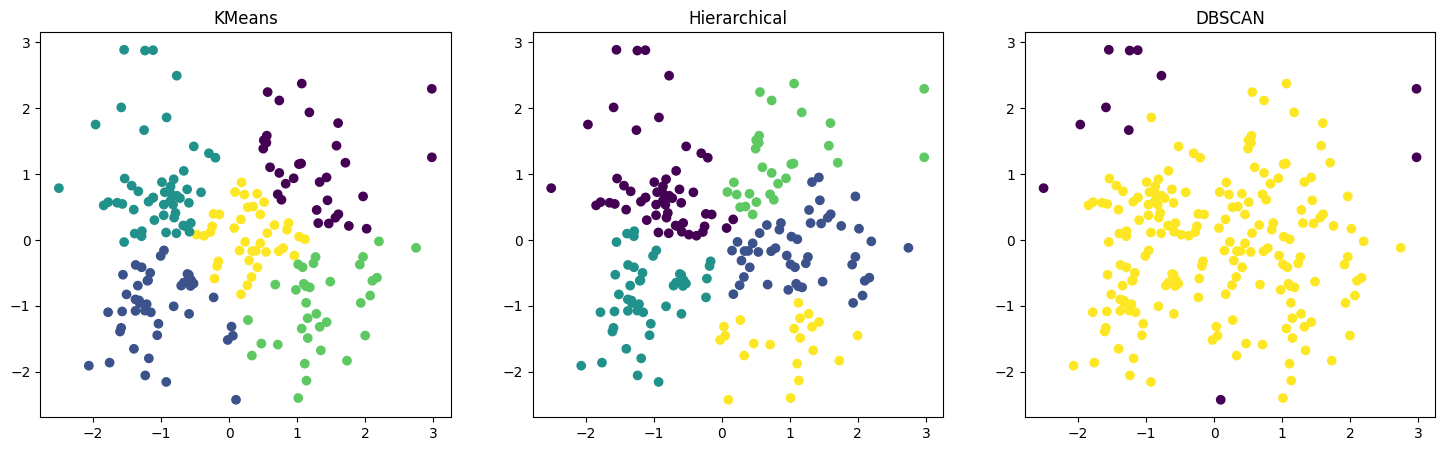

In [46]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

ax[0].scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=kmeans_labels
)

ax[0].set_title("KMeans")

ax[1].scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=hc_labels
)

ax[1].set_title("Hierarchical")

ax[2].scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=db_labels
)

ax[2].set_title("DBSCAN")

plt.show()

In [47]:
summary = pd.DataFrame({

'Algorithm':['KMeans',
             'Hierarchical',
             'DBSCAN'],

'Silhouette Score':
[
kmeans_score,
hc_score,
db_score
],

'Clusters Found':
[
len(np.unique(kmeans_labels)),
len(np.unique(hc_labels)),
len(set(db_labels)) -
(1 if -1 in db_labels else 0)
],

'Noise Points':
[
0,
0,
sum(db_labels==-1)
]

})

print(summary)

      Algorithm  Silhouette Score  Clusters Found  Noise Points
0        KMeans          0.370485               5             0
1  Hierarchical          0.356265               5             0
2        DBSCAN          0.375259               1            11


In [48]:
df['Cluster'] = kmeans_labels

df.to_csv(
    "clustered_customers.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [49]:
clustered_df = pd.read_csv(
    "clustered_customers.csv"
)

clustered_df.head()

,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100),Cluster
0,19,3,1,15,39,2
1,21,2,2,15,81,2
2,20,2,1,16,6,4
3,23,3,3,16,77,2
4,31,5,1,17,40,4


In [50]:
new_customers = pd.DataFrame({

'Gender':[1,0,1,0,1],

'Age':[22,45,31,28,52],

'Annual Income (k$)':
[20,80,60,25,100],

'Spending Score (1-100)':
[80,20,55,90,10]

})